In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import datetime     
from tqdm import tqdm
from collections import Counter


In [26]:
data_path = '../../Smart attack Algorithm/data/Car Hacking Dataset/'
benign_data_path = os.path.join(data_path, 'benign_data.csv')
attack_data_path = os.path.join(data_path, 'DoS_dataset.csv')

In [27]:
benign_data = pd.read_csv(benign_data_path)

benign_data.head()

,Timestamp,ID,DLC,Payload,label
0,1.479121e+09,0350,8,052884666d0000a2,0
1,1.479121e+09,02c0,8,1400000000000000,0
2,1.479121e+09,0430,8,0000000000000000,0
3,1.479121e+09,04b1,8,0000000000000000,0
4,1.479121e+09,01f1,8,0000000000000000,0


Number of unique payloads for each ID in the benign dataset:
ID
0002      152
00a0     4677
00a1     1487
0130    50243
0131    48723
0140      344
0153        1
018f      626
01f1    16384
0260    39906
02a0       48
02b0    31583
02c0        1
0316    25788
0329     3885
0350      213
0370       83
0430        1
043f    28366
0440    32868
04b1    19401
04f0      609
0545     1371
05a0        1
05a2        3
05f0        1
0690        2
Name: Payload, dtype: int64


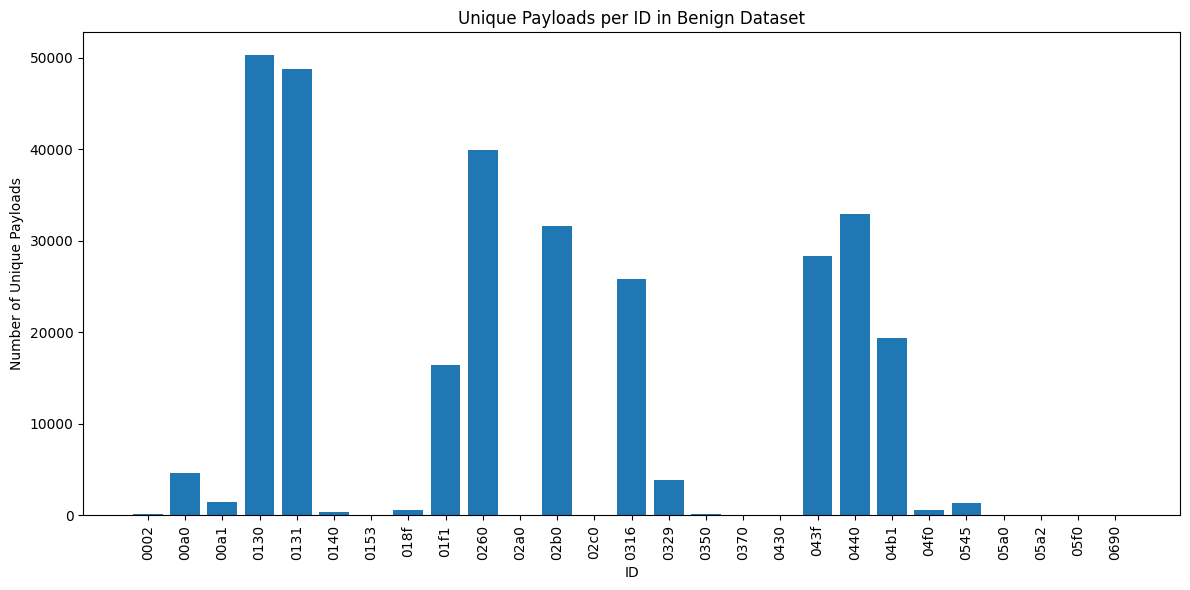

In [29]:
##Number of unique payloads for each ID in the benign dataset
unique_payloads = benign_data.groupby('ID')['Payload'].nunique()
print("Number of unique payloads for each ID in the benign dataset:")
print(unique_payloads)
# Plotting the number of unique payloads for each ID
plt.figure(figsize=(12, 6))
plt.bar(unique_payloads.index, unique_payloads.values)
plt.xlabel('ID')
plt.ylabel('Number of Unique Payloads')
plt.title('Unique Payloads per ID in Benign Dataset')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [4]:
benign_data = benign_data.iloc[:]

In [5]:
def shift_columns(df):
    
    for dlc in [2,5,6]:

        df.loc[df['DLC'] == dlc, df.columns[3:]] = df.loc[df['DLC'] == dlc, df.columns[3:]].shift(periods=8-dlc, axis='columns', fill_value='00')

    return df
    

def read_ch_data(data_path):
    
    columns = ['Timestamp','ID', 'DLC', 'data0', 'data1', 'data2', 'data3', 'data4', 
           'data5', 'data6', 'data7', 'label']
    
    data = pd.read_csv(data_path, names = columns)

    data = shift_columns(data)
    
    ##Replacing all NaNs with '00' 
    data = data.replace(np.NaN, '00')
    
    ##Joining all data columns to put all data in one column
    data_cols = ['data0', 'data1', 'data2', 'data3', 'data4', 'data5', 'data6', 'data7']
    
    ##The data column is in hexadecimal
    data['Payload'] = data[data_cols].apply(''.join, axis=1)
    data.drop(columns = data_cols, inplace = True, axis = 1)
        
    data = data.assign(IAT=data['Timestamp'].diff().fillna(0))
    data = data[['Timestamp', 'ID','DLC','Payload', 'IAT', 'label']]
    data['label'].replace({'R' : 0, 'T' : 1}, inplace = True)
    
    return data

# attack_data = read_ch_data(attack_data_path)
# attack_data.head()

In [6]:
def data_len(df):
    if 'Timestamp' in df.columns:
        # Ensure the Timestamp column is sorted
        df = df.sort_values(by='Timestamp')
        
        # Compute time difference
        time_diff = df['Timestamp'].iloc[-1] - df['Timestamp'].iloc[0]
        
        # Convert to HH:MM:SS:Milliseconds format
        hours, remainder = divmod(time_diff, 3600)
        minutes, remainder = divmod(remainder, 60)
        seconds, milliseconds = divmod(remainder, 1)
        
        time_str = f"{int(hours):02}:{int(minutes):02}:{int(seconds):02}:{int(milliseconds * 1000):03}"
        
        return time_str
    else:
        return "Timestamp column not found in dataframe"

In [7]:
hex_to_dec = lambda x: int(x, 16)

def transform_data(data):

    data['ID'] = data['ID'].apply(hex_to_dec)
    data['Payload'] = data['Payload'].apply(hex_to_dec)

    return data

hex_to_dec = lambda x: int(x, 16)

# Function to handle conversion
def convert_hex_column(column):
    def convert_value(value):
        try:
            # Try to convert using hex_to_dec
            return hex_to_dec(value)
        except ValueError:
            # If ValueError occurs, it means the value is in scientific notation
            return int(float(value))
    
    return column.apply(convert_value)


benign_data = transform_data(benign_data)


In [24]:
benign_data.head()

,ID,DLC,Payload,label
0,848,8,371692544708313250,0
1,704,8,1441151880758558720,0
2,1072,8,0,0
3,1201,8,0,0
4,497,8,0,0


In [9]:
print(benign_data.head())

      Timestamp    ID  DLC              Payload  label
0  1.479121e+09   848    8   371692544708313250      0
1  1.479121e+09   704    8  1441151880758558720      0
2  1.479121e+09  1072    8                    0      0
3  1.479121e+09  1201    8                    0      0
4  1.479121e+09   497    8                    0      0


In [10]:
benign_data.drop(columns=['Timestamp'], axis=1, inplace=True)

In [11]:
def split_into_windows(df, window_size = 50, label = False):
    
    ##Split the data into windows of size 50 by default
    ## Every unique ID will have its own windows
    ##window dict will contain the windows for each ID 
    ##Key will be ID and value will be the window list for that ID
    ## value will be a list of dataframes, each of size window_size
    ##take in an arguments label, if the label is True, then there is label column in the dataframe
    ##for window_size messsages of each ID if there is one true label in the window, then the label for that window will be 1, else 0, return a label dictionary separately
    # df.drop(columns = ['Timestamp'], inplace=True, errors='ignore')
    window_dict = {}
    label_dict = {}
    id_list = list(df['ID'].unique())

    for ids in id_list:
        id_df = df[df['ID'] == ids].reset_index(drop=True)
        
        
        # start_time = id_df['Timestamp'].min()
        # end_time = id_df['Timestamp'].max()
        
        windows = []
        window_labels = []
        
        ##Each window will have window_size number of messages
        num_windows = len(id_df)// window_size
        for i in tqdm(range(num_windows)):
            # Extract data for the current window
            window = id_df.iloc[i * window_size : (i + 1) * window_size].values
            
            if len(window) != 0:
                windows.append(window)
                # print(window)
                
                # Assign window label: 1 if any label is 1 in the window, else 0
                if label and (window[-1] == 1).any():
                    window_labels.append(1)
                else:
                    window_labels.append(0)

        
        if windows:
            window_dict[ids] = windows
        if label and window_labels:
            label_dict[ids] = window_labels
    
    return window_dict, label_dict, len(window_dict)





In [12]:
window_dict, _, num_windows = split_into_windows(benign_data, window_size=50, label=True)
# print(f"Number of windows created: {num_windows}")

100%|██████████| 101/101 [00:00<00:00, 33889.98it/s]


In [13]:
for ids, windows in window_dict.items():
    print(f"ID: {ids}, Number of windows: {len(windows)}")
    # Uncomment the next line to see the first window for each ID
    # print(f"First window for ID {ids}: {windows[0]}")

ID: 848, Number of windows: 1013
ID: 704, Number of windows: 1013
ID: 1072, Number of windows: 506
ID: 1201, Number of windows: 506
ID: 497, Number of windows: 506
ID: 339, Number of windows: 1012
ID: 2, Number of windows: 1012
ID: 399, Number of windows: 1013
ID: 304, Number of windows: 1012
ID: 305, Number of windows: 1012
ID: 320, Number of windows: 1012
ID: 608, Number of windows: 1013
ID: 672, Number of windows: 1013
ID: 790, Number of windows: 1013
ID: 809, Number of windows: 1013
ID: 1349, Number of windows: 1013
ID: 688, Number of windows: 1012
ID: 1087, Number of windows: 1012
ID: 880, Number of windows: 1012
ID: 1088, Number of windows: 1012
ID: 1264, Number of windows: 506
ID: 1520, Number of windows: 202
ID: 1440, Number of windows: 10
ID: 1442, Number of windows: 10
ID: 1680, Number of windows: 101
ID: 160, Number of windows: 101
ID: 161, Number of windows: 101


In [14]:
def calculate_entropy(window_dict):
    entropy_dict = {}

    for ids, windows in window_dict.items():
        id_entropies = []       

        for window in windows:
            # window shape: (window_size, num_columns)
            # We'll convert each row into a tuple to count unique patterns
            row_tuples = [tuple(row) for row in window]
            counts = Counter(row_tuples)

            total = sum(counts.values())
            probs = [count / total for count in counts.values()]
            
            # Compute entropy manually
            entropy = -sum(p * np.log2(p) for p in probs if p > 0)
            id_entropies.append(entropy)
        
        entropy_dict[ids] = id_entropies

    return entropy_dict

In [15]:
entropy_dict = calculate_entropy(window_dict)

In [16]:
##Print the mean and std-dev of the entropy for each ID
for ids, entropies in entropy_dict.items():
    mean_entropy = np.mean(entropies)
    std_entropy = np.std(entropies)
    print(f"ID: {ids}, Mean Entropy: {mean_entropy:.4f}, Std Dev: {std_entropy:.4f}")

ID: 848, Mean Entropy: 4.2008, Std Dev: 0.2088
ID: 704, Mean Entropy: 0.0000, Std Dev: 0.0000
ID: 1072, Mean Entropy: 0.0000, Std Dev: 0.0000
ID: 1201, Mean Entropy: 4.6055, Std Dev: 1.8996
ID: 497, Mean Entropy: 4.1868, Std Dev: 2.0346
ID: 339, Mean Entropy: 0.0000, Std Dev: 0.0000
ID: 2, Mean Entropy: 5.6143, Std Dev: 0.0386
ID: 399, Mean Entropy: 1.0091, Std Dev: 1.0829
ID: 304, Mean Entropy: 5.6419, Std Dev: 0.0088
ID: 305, Mean Entropy: 5.6402, Std Dev: 0.0128
ID: 320, Mean Entropy: 5.6439, Std Dev: 0.0000
ID: 608, Mean Entropy: 4.3706, Std Dev: 0.9966
ID: 672, Mean Entropy: 2.0490, Std Dev: 0.2000
ID: 790, Mean Entropy: 4.4092, Std Dev: 0.8288
ID: 809, Mean Entropy: 2.4321, Std Dev: 0.6415
ID: 1349, Mean Entropy: 2.9840, Std Dev: 0.5144
ID: 688, Mean Entropy: 5.3768, Std Dev: 0.5022
ID: 1087, Mean Entropy: 4.4425, Std Dev: 1.8028
ID: 880, Mean Entropy: 0.1782, Std Dev: 0.3887
ID: 1088, Mean Entropy: 4.4299, Std Dev: 1.8190
ID: 1264, Mean Entropy: 1.3668, Std Dev: 1.0371
ID: 1520,

In [17]:
##Boxplot of entropy values for each ID, each ID will have its own boxplot
def plot_entropy_boxplots(entropy_dict):
    plt.figure(figsize=(15, 10))
    
    # Create a DataFrame for plotting
    entropy_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in entropy_dict.items()]))
    
    # Plot boxplot
    sns.boxplot(data=entropy_df)
    
    plt.title('Entropy Distribution per ID')
    plt.xlabel('ID')
    plt.ylabel('Entropy')
    plt.xticks(rotation=90)
    plt.grid(axis='y')
    plt.show()


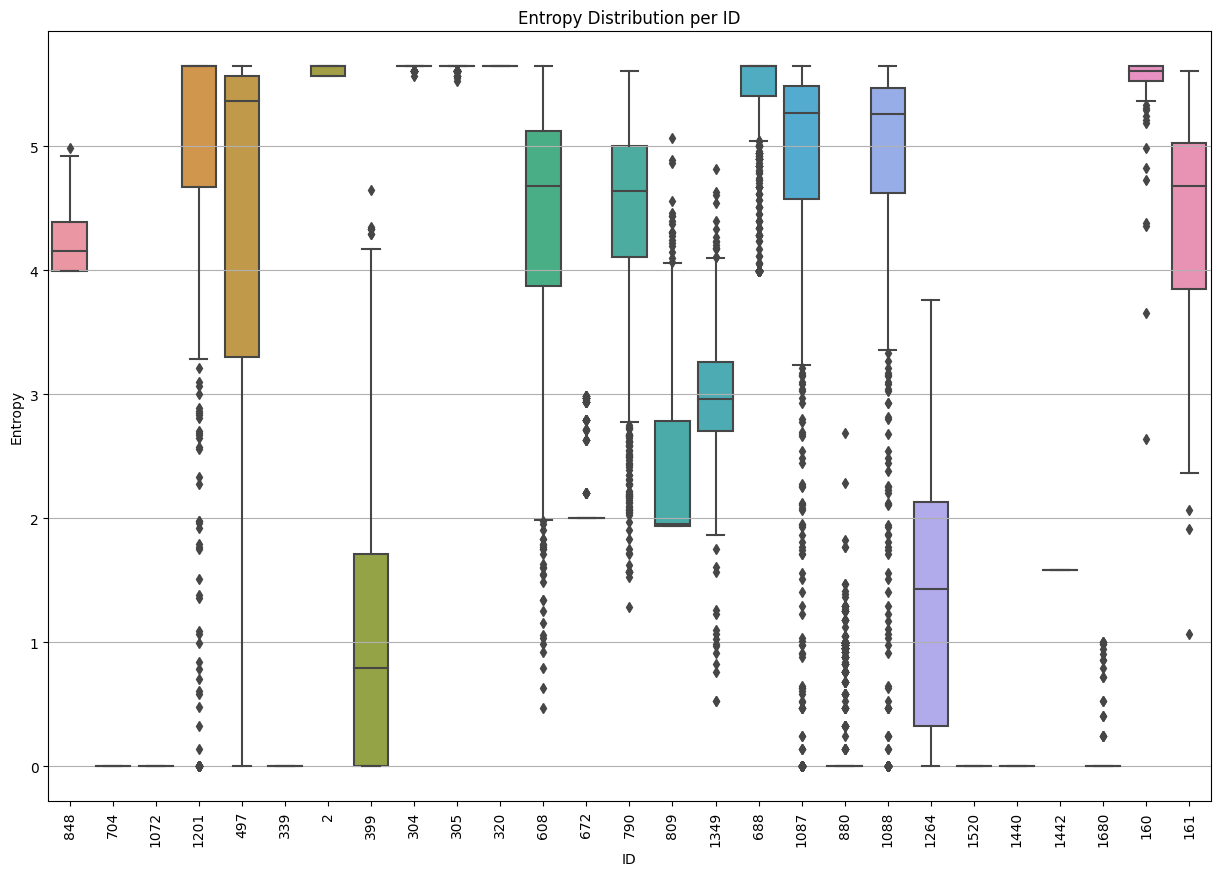

In [18]:
plot_entropy_boxplots(entropy_dict)

In [19]:
def determine_threshold(entropy_dict):
    
    """Threshold range is [mean - k * std, mean + k * std]
       where k is a multiplier to adjust the sensitivity of the threshold.
        Every ID will have its own threshold range.
        start with k = 0.5 and increase it until no false positives are found.
    """

    thresholds = {}
    k_values = {}

    for ids, entropies in entropy_dict.items():
        mean = np.mean(entropies)
        std = np.std(entropies)

        k = 0.5  # Start with k = 0.5
        flag = False

        while not flag:
            threshold = (mean - k * std, mean + k * std)
            # Check for false positives
            false_positives = sum((entropy < threshold[0] or entropy > threshold[1]) for entropy in entropies)

            if false_positives == 0:
                flag = True  # Stop when no false positives
                thresholds[ids] = threshold
                k_values[ids] = k
            else:
                k += 0.5  # Increment k and try again

    return thresholds, k_values

    



In [20]:
thresholds, k_values = determine_threshold(entropy_dict)
for ids, threshold in thresholds.items():
    print(f"ID: {ids}, Threshold Range: {threshold}, k Value: {k_values[ids]}")

ID: 848, Threshold Range: (3.3656820053655228, 5.035990861844811), k Value: 4.0
ID: 704, Threshold Range: (0.0, 0.0), k Value: 0.5
ID: 1072, Threshold Range: (0.0, 0.0), k Value: 0.5
ID: 1201, Threshold Range: (-0.14351163536201028, 9.354559097276459), k Value: 2.5
ID: 497, Threshold Range: (-0.8997788827022424, 9.273465269458569), k Value: 2.5
ID: 339, Threshold Range: (0.0, 0.0), k Value: 0.5
ID: 2, Threshold Range: (5.556368528962968, 5.672213415803879), k Value: 1.5
ID: 399, Threshold Range: (-2.781070609474853, 4.799186078093404), k Value: 3.5
ID: 304, Threshold Range: (5.562237411658202, 5.721522398721293), k Value: 9.0
ID: 305, Threshold Range: (5.518845087954528, 5.761564726871525), k Value: 9.5
ID: 320, Threshold Range: (5.643856189774728, 5.64385618977473), k Value: 1.0
ID: 608, Threshold Range: (0.38413466906748805, 8.357122839927733), k Value: 4.0
ID: 672, Threshold Range: (1.0489539364259632, 3.049031306088213), k Value: 5.0
ID: 790, Threshold Range: (1.0938909923772515, 7

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


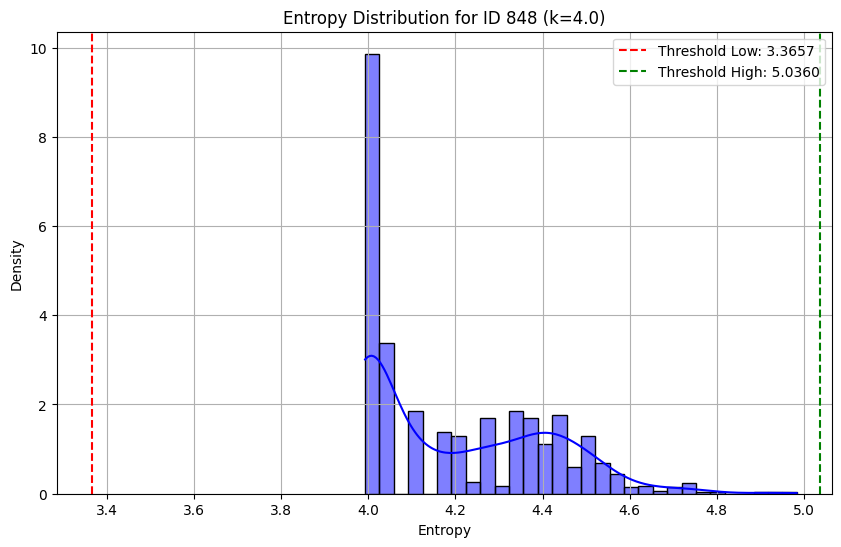

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


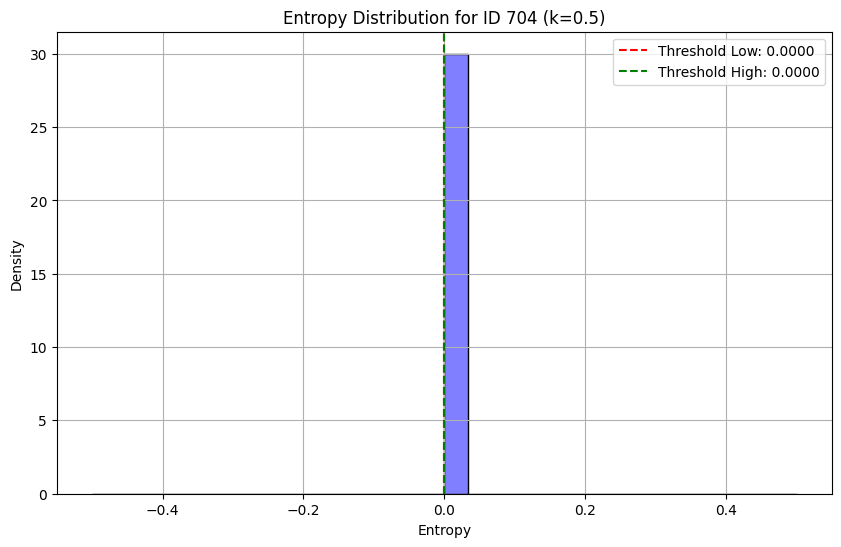

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


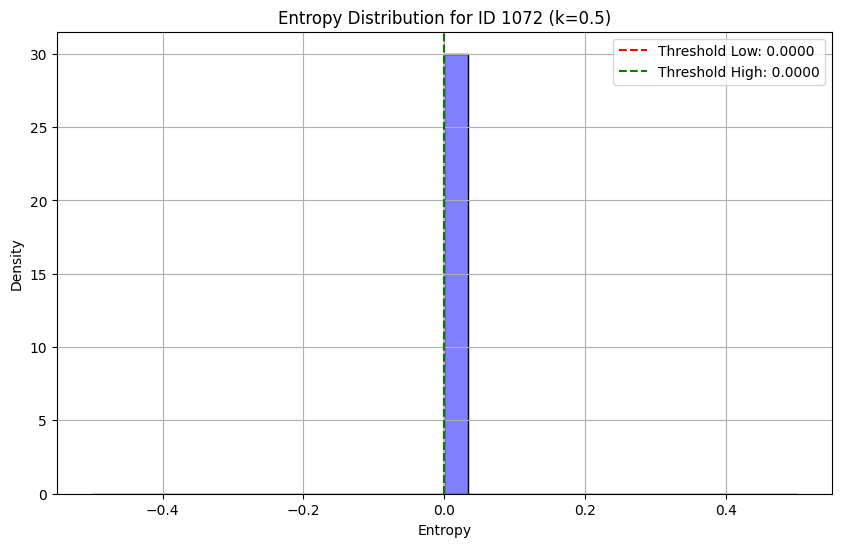

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


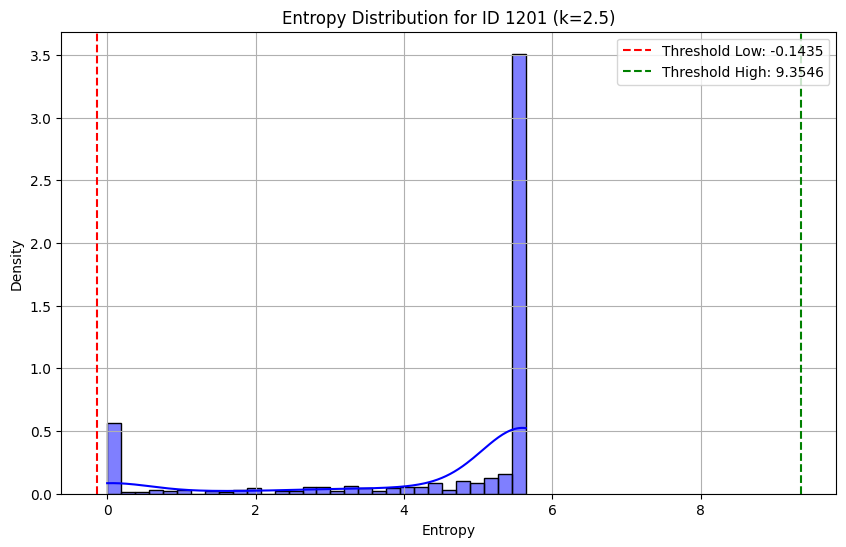

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


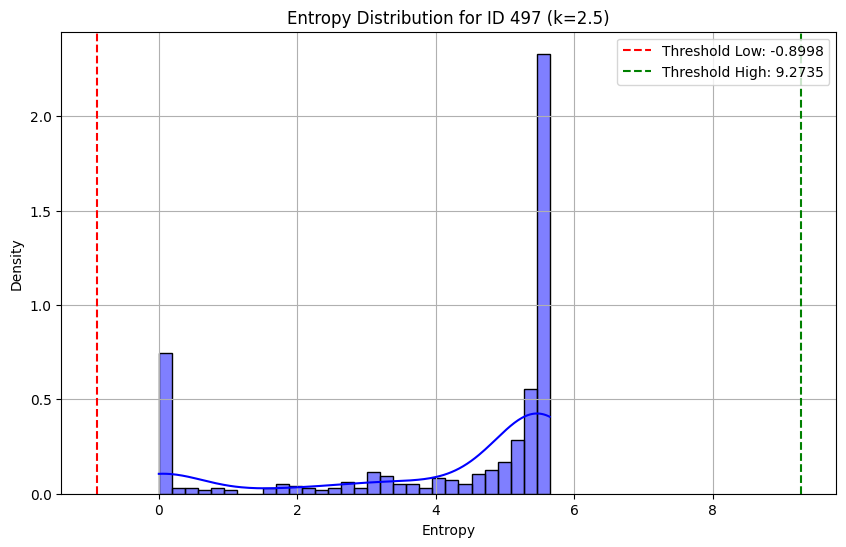

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


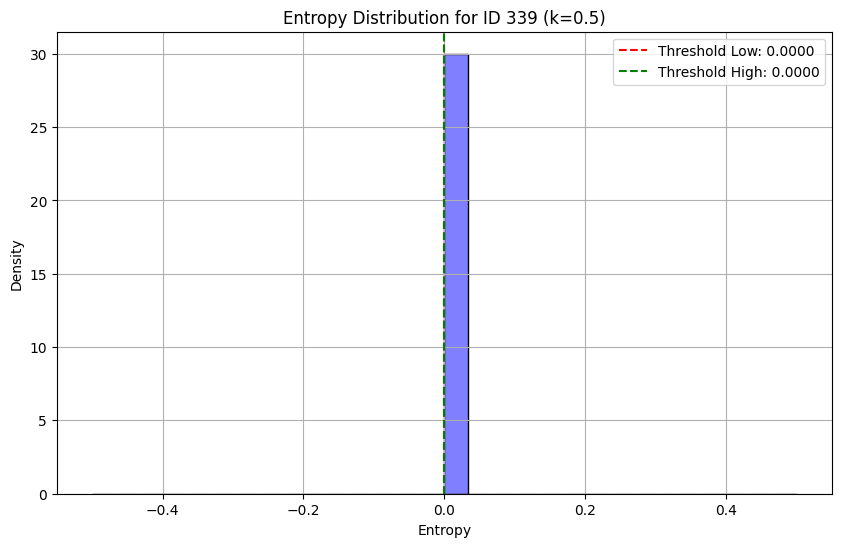

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


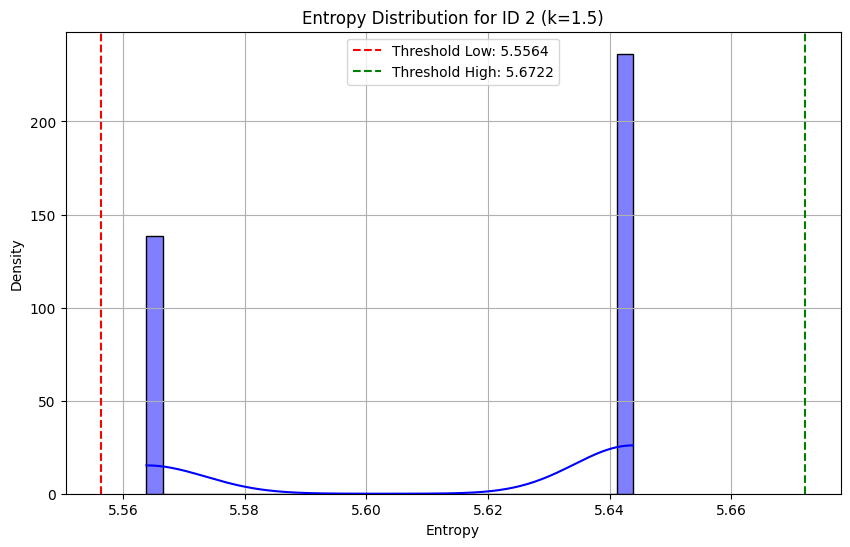

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


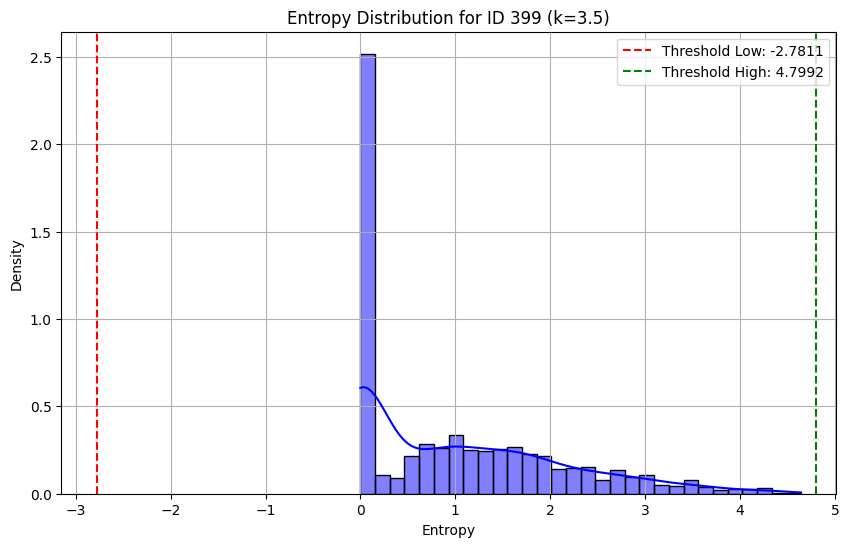

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


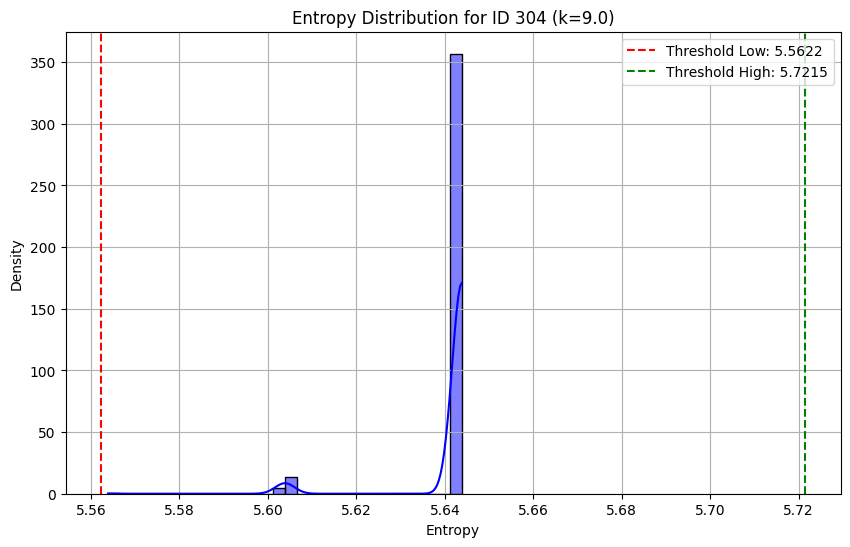

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


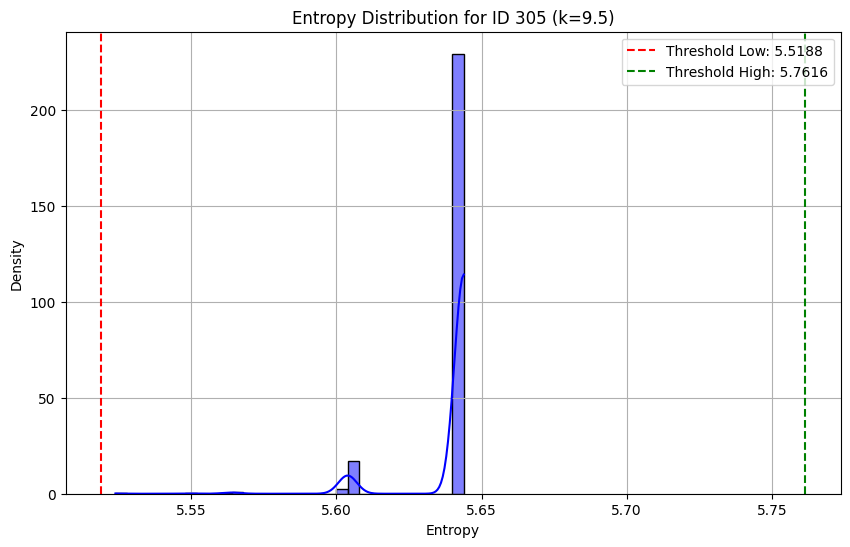

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


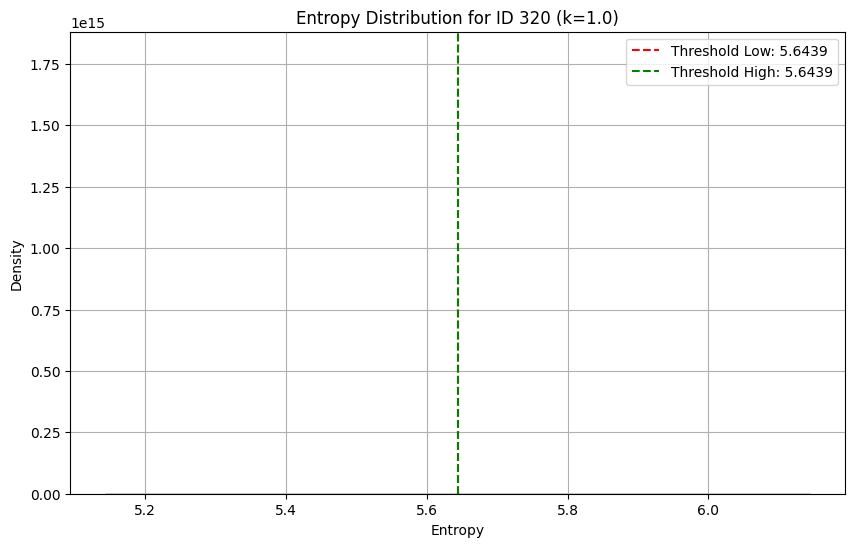

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


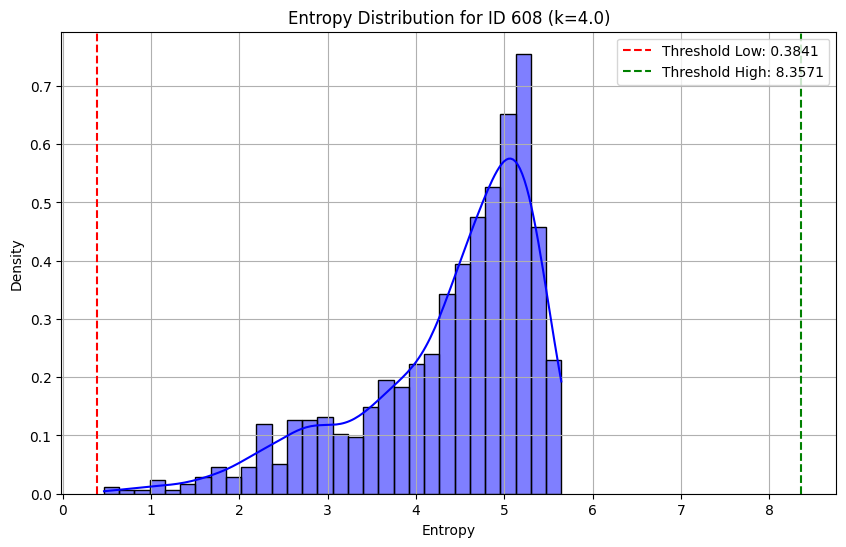

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


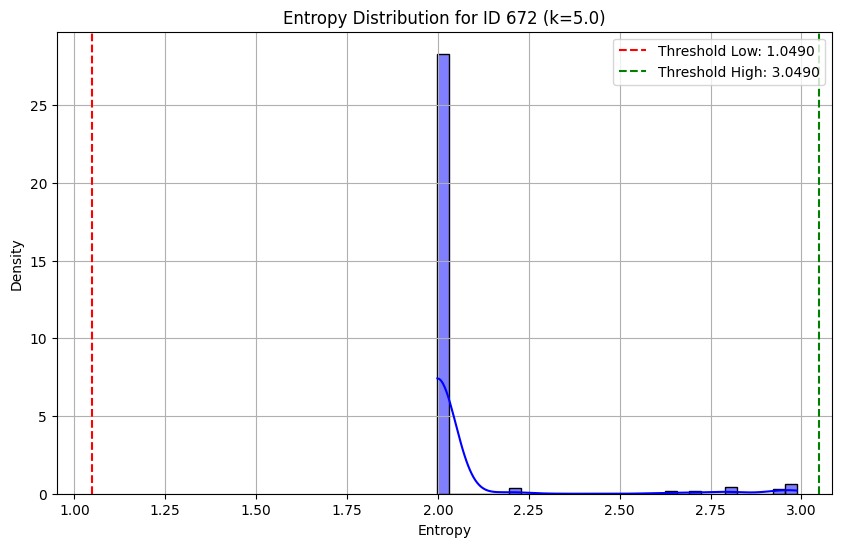

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


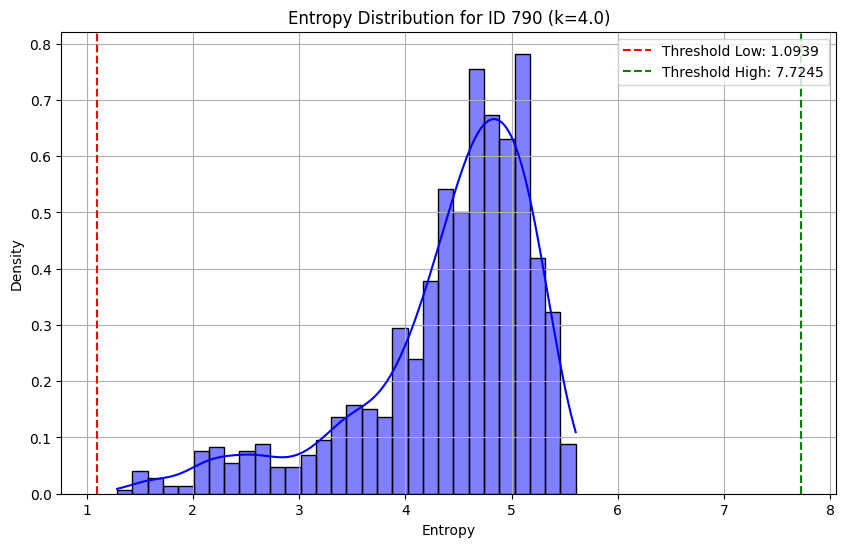

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


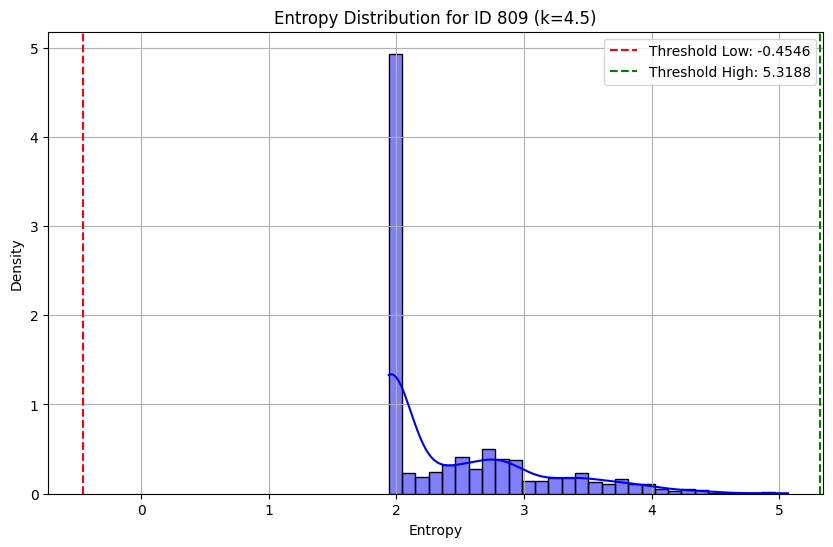

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


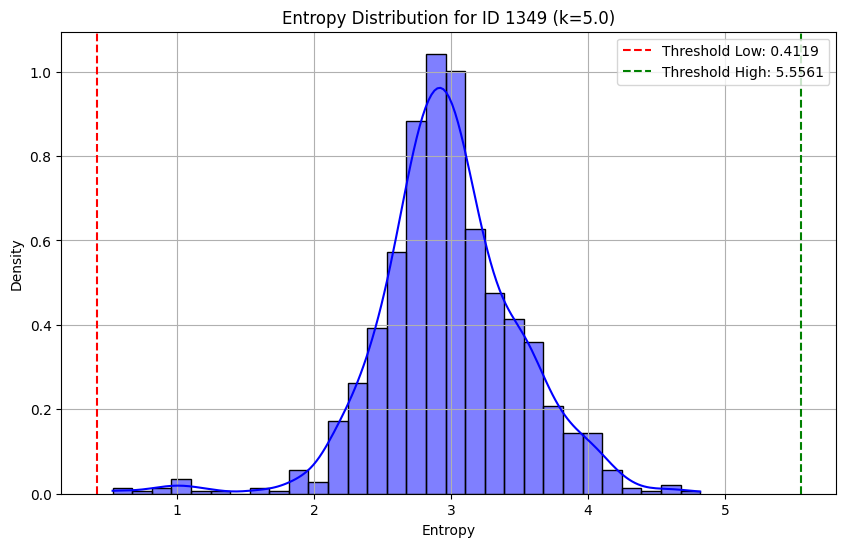

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


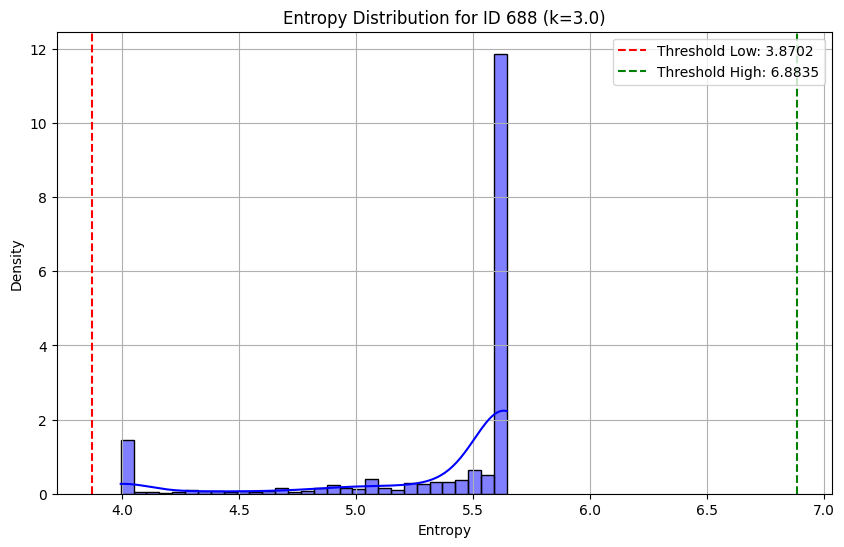

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


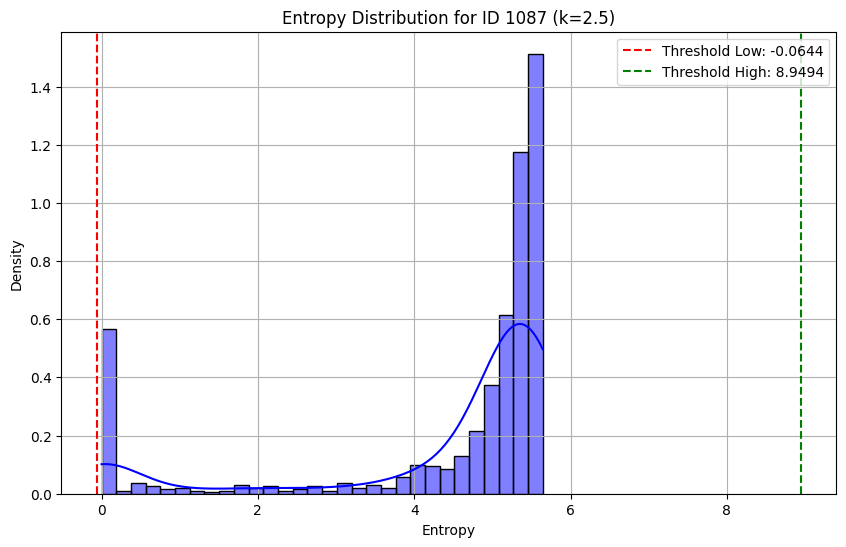

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


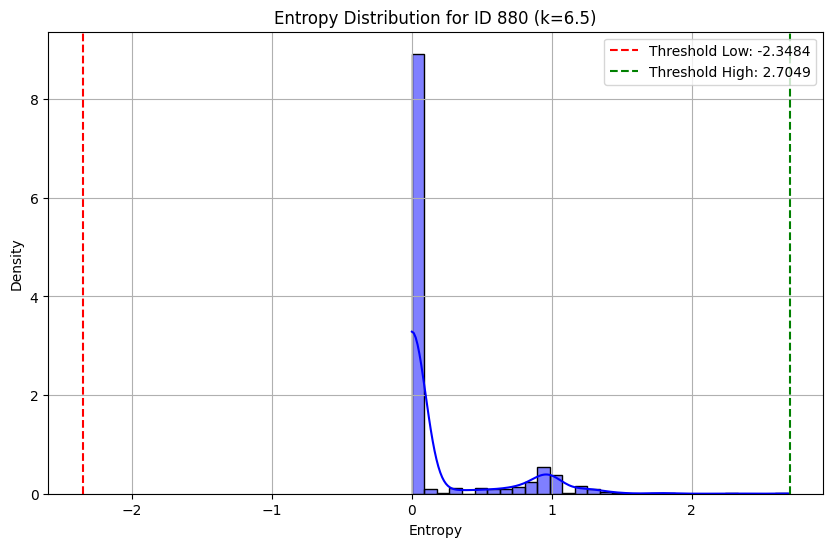

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


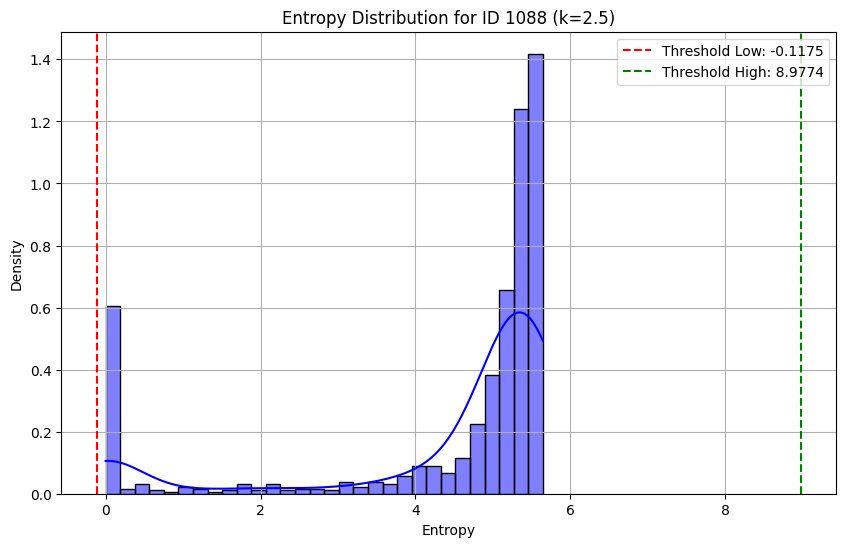

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


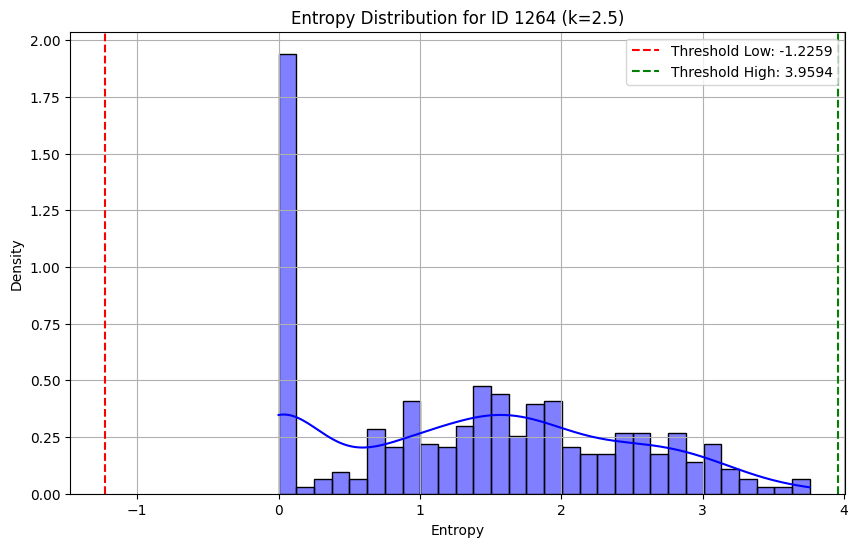

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


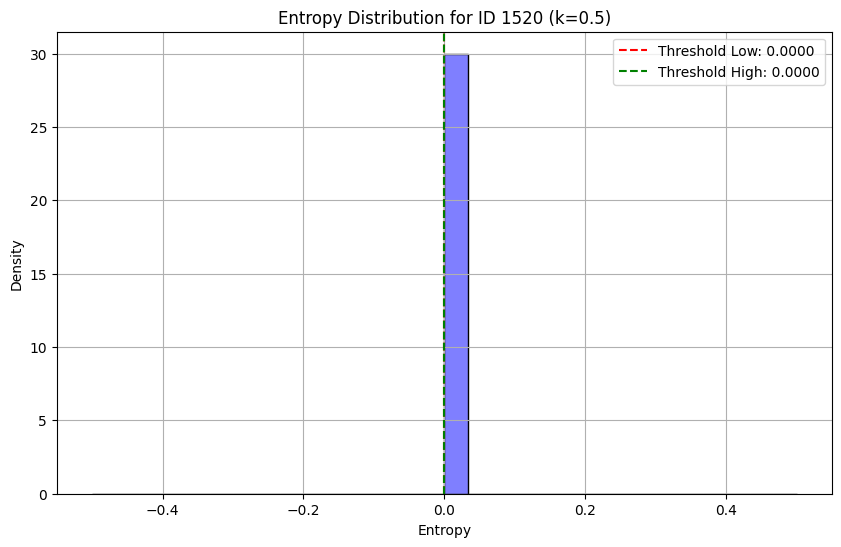

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


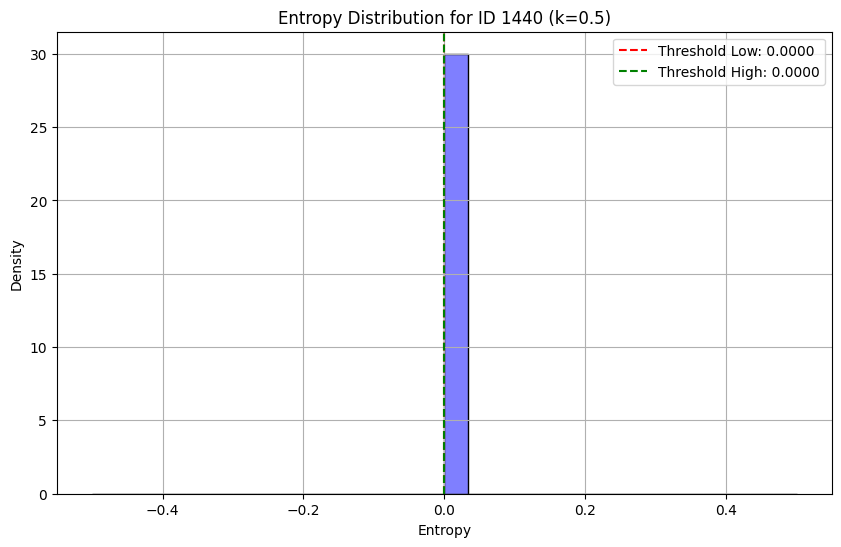

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


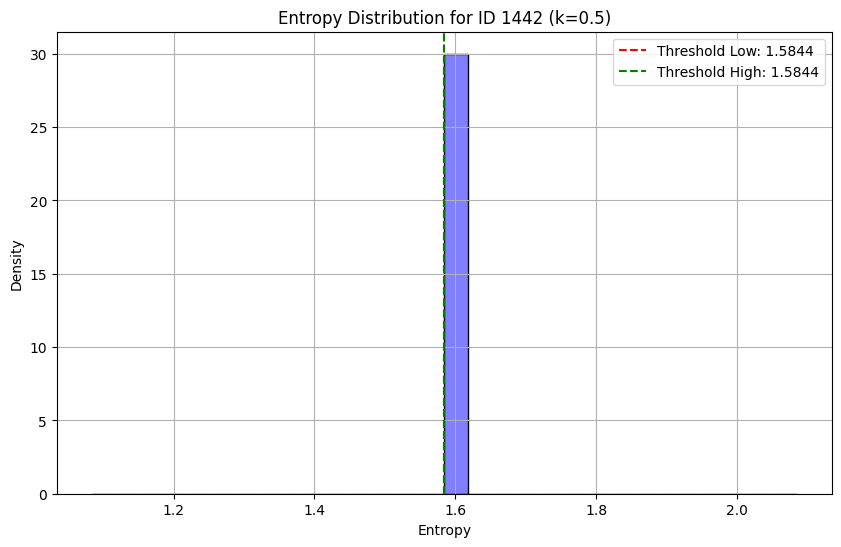

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


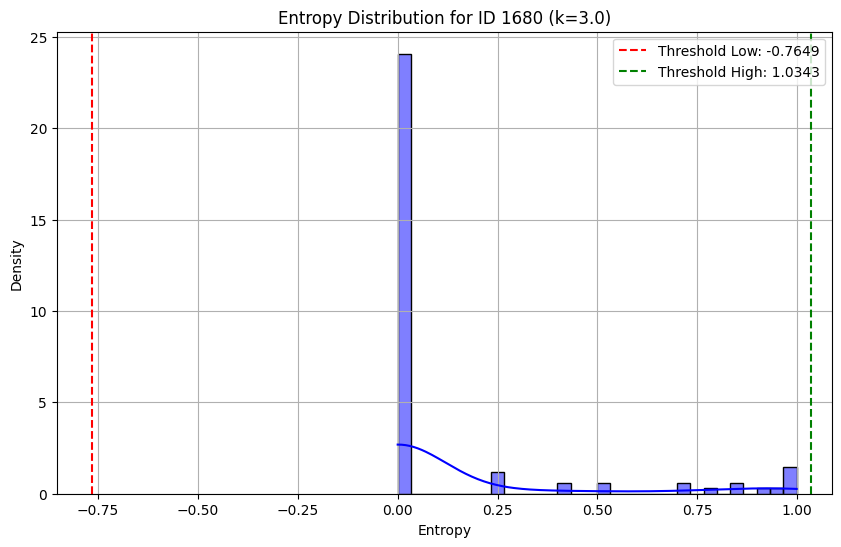

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


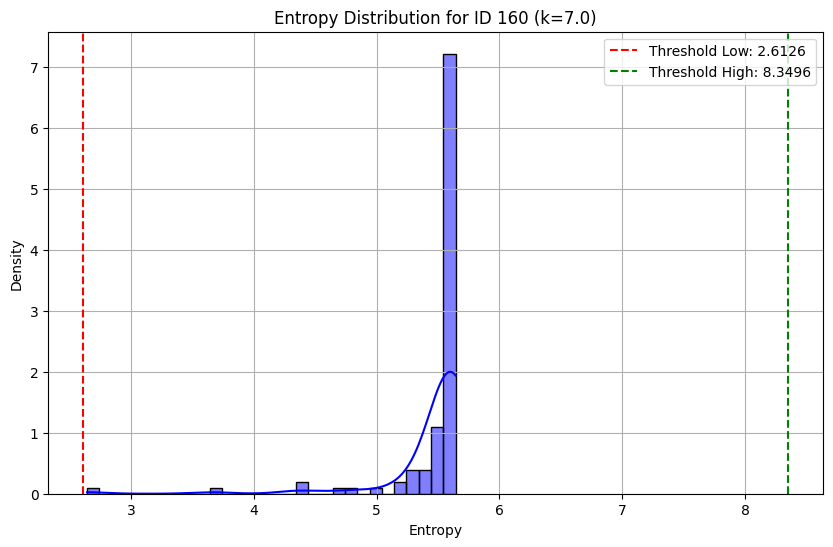

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


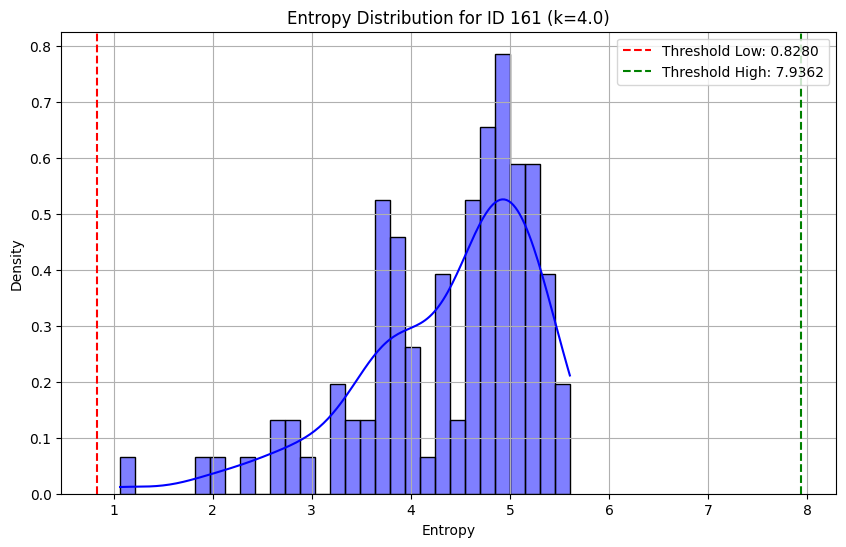

In [23]:
##Plot the thresholds along with distribution of entropies for each ID
#Separate histograms for each ID with threshold lines
##k value should be on the title of the plot
def plot_entropy_with_thresholds(entropy_dict, thresholds, k_values):
    for ids, entropies in entropy_dict.items():
        plt.figure(figsize=(10, 6))
        
        # Plot histogram of entropies
        sns.histplot(entropies, bins=30, kde=True, color='blue', stat='density')
        
        # Plot threshold lines
        threshold = thresholds[ids]
        plt.axvline(threshold[0], color='red', linestyle='--', label=f'Threshold Low: {threshold[0]:.4f}')
        plt.axvline(threshold[1], color='green', linestyle='--', label=f'Threshold High: {threshold[1]:.4f}')
        
        plt.title(f'Entropy Distribution for ID {ids} (k={k_values[ids]})')
        plt.xlabel('Entropy')
        plt.ylabel('Density')
        plt.legend()
        plt.grid()
        plt.show()
plot_entropy_with_thresholds(entropy_dict, thresholds, k_values)